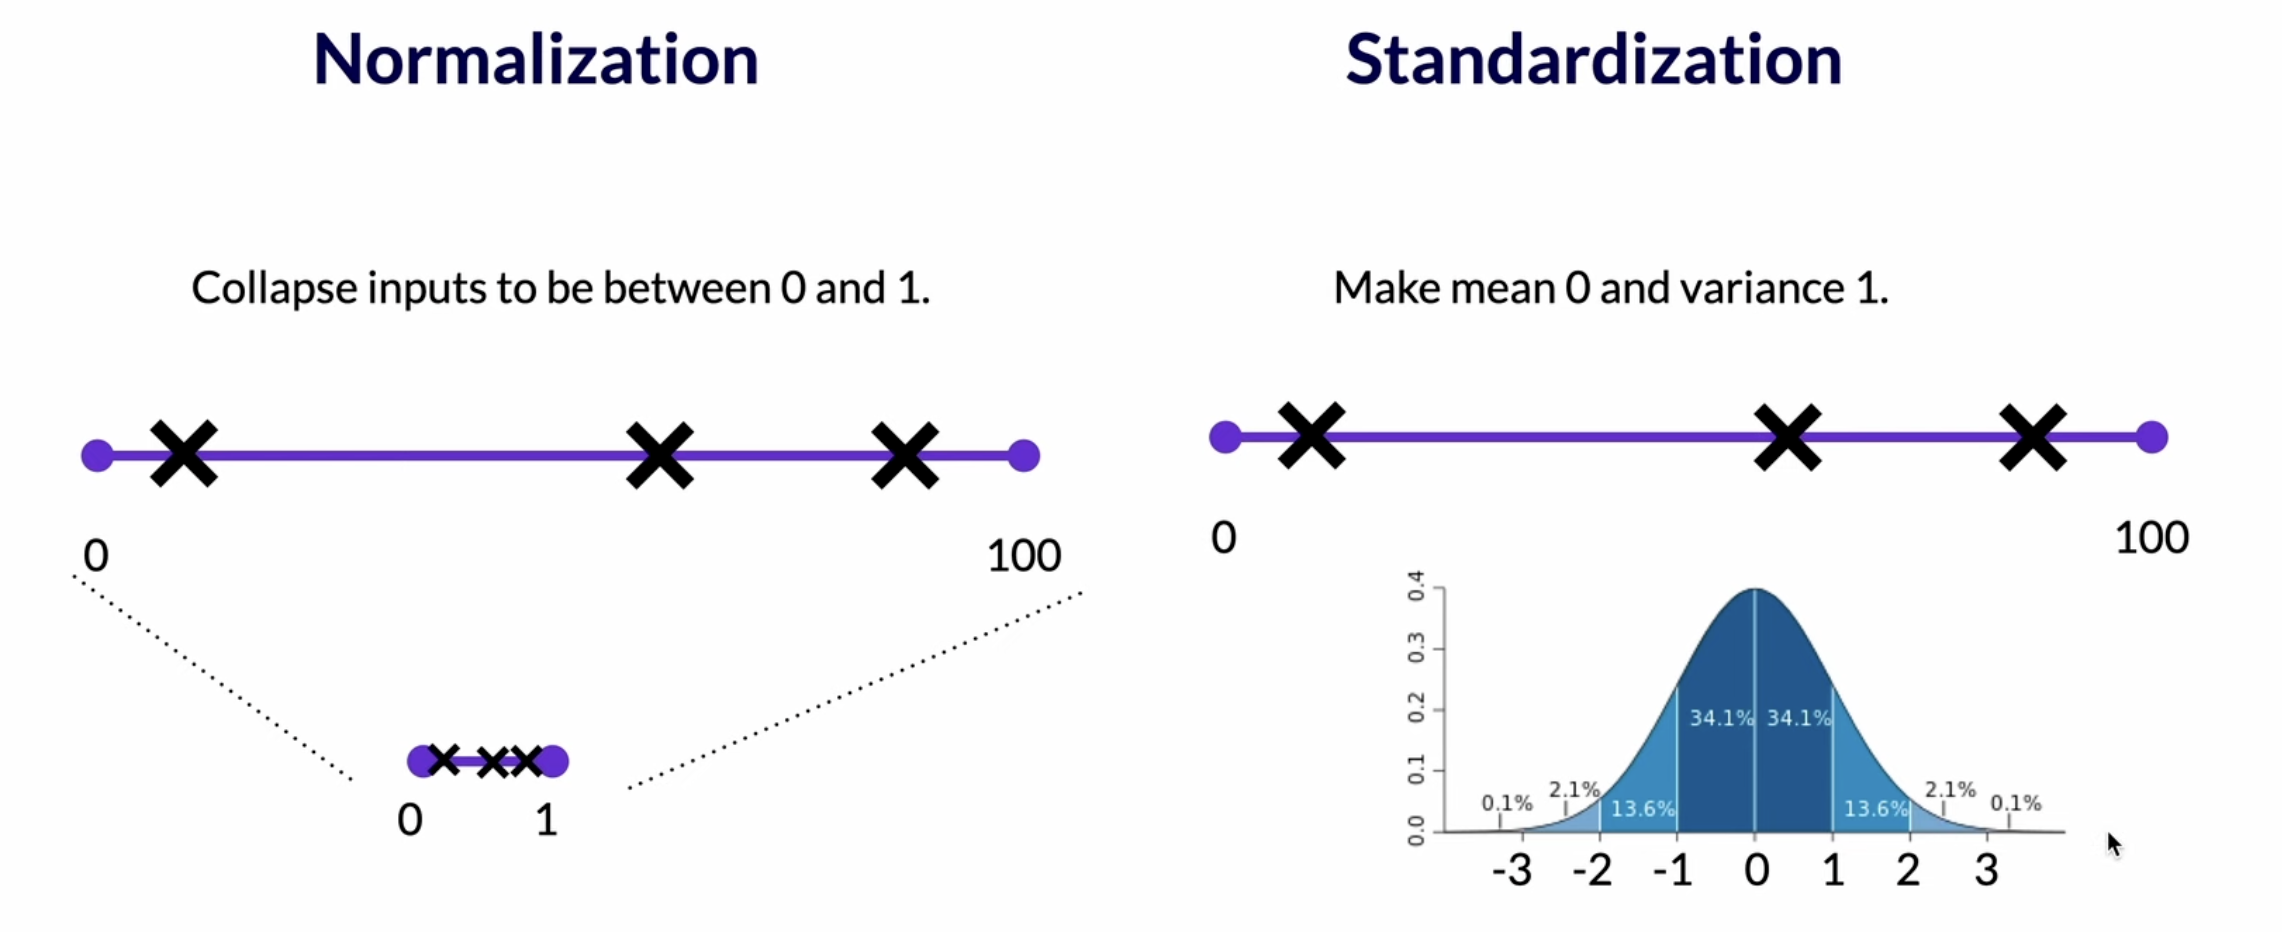

# Normalization Techniques in CNN

CNN model layers ထဲမှာ သုံးတဲ့ **normalization techniques** တွေကို တစ်ခုချင်းစီ ရှင်းပြမယ်။

## ဘာကြောင့် Normalization လိုအပ်လဲ?

Training လုပ်နေတဲ့အချိန် layer တစ်ခုချင်းစီရဲ့ input distribution က **ပြောင်းလဲနေတယ်** (Internal Covariate Shift)။ ဒါကြောင့်:
- Training **slow** ဖြစ်တယ်
- Learning rate ကြီးကြီး သုံးလို့ **မရဘူး** (gradient explosion/vanishing)
- Weight initialization ကို **sensitive** ဖြစ်တယ်

Normalization က activations ကို **re-center & re-scale** လုပ်ပေးပြီး ဒီ problems တွေကို ဖြေရှင်းပေးတယ်။

## Normalization Types
| Type | PyTorch | Normalize Over | Primary Use |
|------|---------|---------------|-------------|
| **Batch Norm** | `nn.BatchNorm2d` | Batch dimension (N) | CNN standard |
| **Layer Norm** | `nn.LayerNorm` | Channel + Spatial (C,H,W) | Transformer, RNN |
| **Instance Norm** | `nn.InstanceNorm2d` | Spatial only (H,W) | Style Transfer |
| **Group Norm** | `nn.GroupNorm` | Channel groups | Small batch sizes |

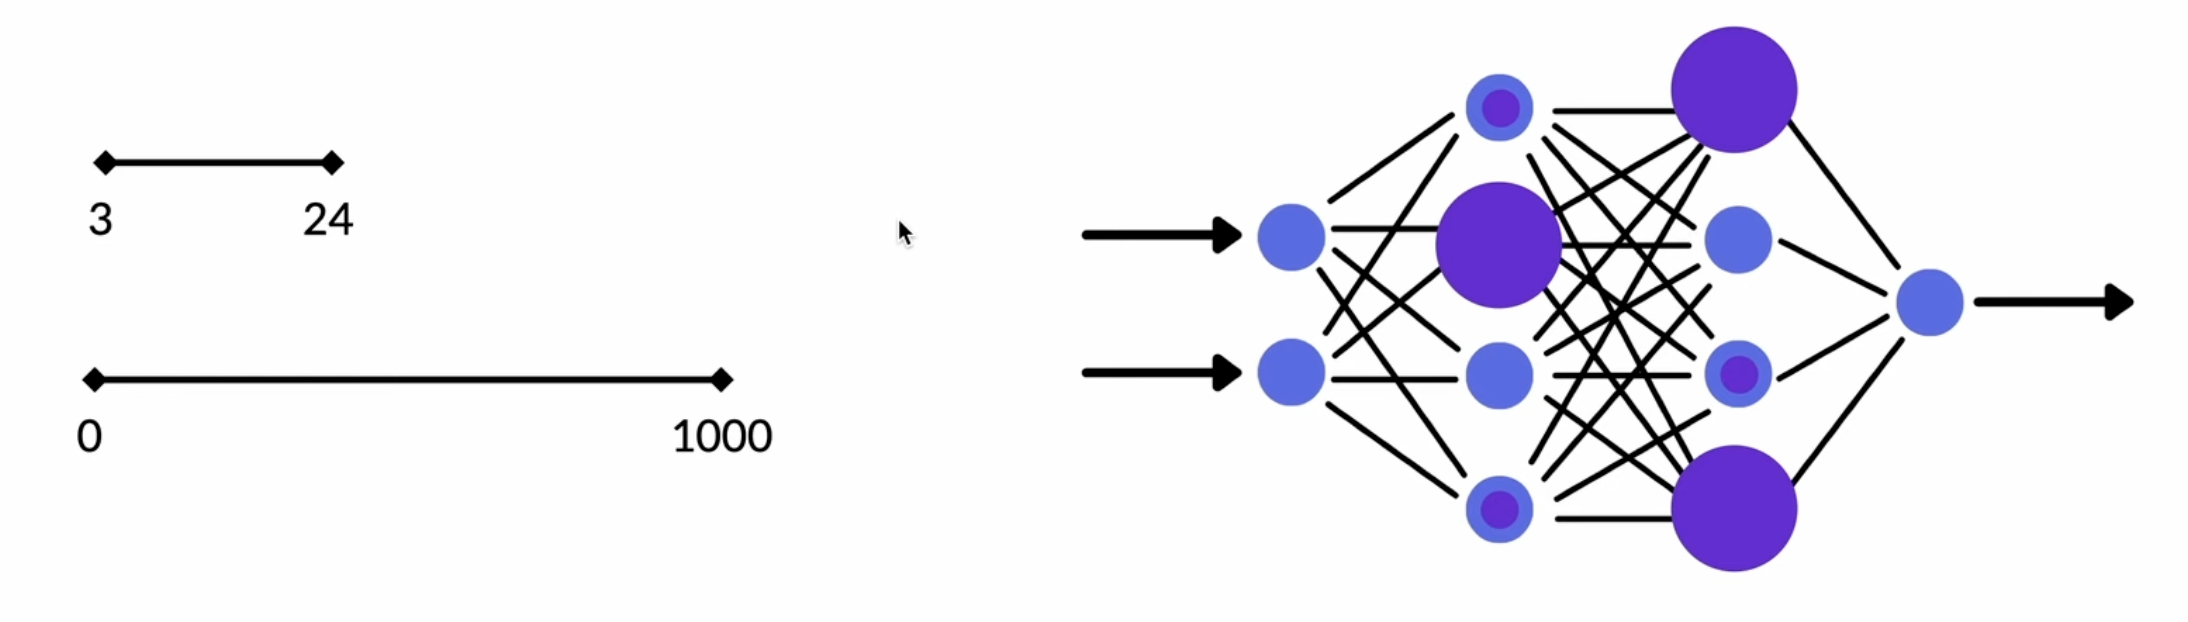

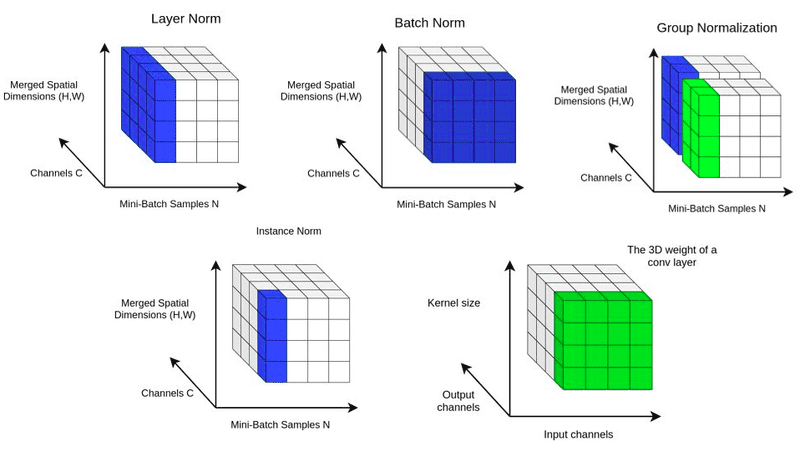


BatchNorm က channel တစ်ခုချင်းစီအတွက် သီးခြားစီ Mean နဲ့ Variance တွက်ပြီး ညှိပေးတာဖြစ်ပါတယ်။ ဒါကြောင့် Channels ၃၂ ခုရှိရင် ညှိပေးရမယ့် Parameters (Scale $\gamma$ နဲ့ Shift $\beta$) ကလည်း ၃၂ စုံစီ ရှိနေမှာဖြစ်ပါတယ်။

In [ ]:
# --- Imports & Setup ---
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

torch.manual_seed(42)

# --- Demo tensor: (N, C, H, W) = (2, 4, 3, 3) ---
# Batch=2 images, 4 channels, 3x3 spatial
x = torch.randn(2, 4, 3, 3) * 5 + 10  # mean≈10, std≈5 (unnormalized)

print("=== Input Tensor ===")
print(f"Shape: {x.shape}  → (N=Batch, C=Channels, H=Height, W=Width)")
print(f"Mean: {x.mean():.4f}")
print(f"Std:  {x.std():.4f}")
print(f"Range: [{x.min():.2f}, {x.max():.2f}]")

## Common Normalization Formula

Normalization technique အားလုံးရဲ့ formula က **base structure** တူတယ်:

$$\hat{x} = \frac{x - \mu}{\sqrt{\sigma^2 + \epsilon}}$$

$$y = \gamma \cdot \hat{x} + \beta$$

- $\mu$ = mean, $\sigma^2$ = variance — **ဘယ် dimension ပေါ်** တွက်လဲ ဆိုတာက technique အလိုက် ကွာတယ်
- $\epsilon$ = small constant (eg. 1e-5) — division by zero ကာကွယ်ဖို့
- $\gamma$ (scale), $\beta$ (shift) = **learnable parameters** — model ကိုယ်တိုင် optimize လုပ်မယ်

**ကွာခြားချက်** = mean/variance ကို **ဘယ် dimensions** ပေါ်မှာ calculate လုပ်လဲ ဆိုတာပဲ

```
Input shape: (N, C, H, W)
                │  │  │  │
                │  │  └──┘ Spatial dimensions
                │  └────── Channel dimension
                └───────── Batch dimension
```

---

## 1. Batch Normalization (`nn.BatchNorm2d`)

**Normalize over:** Batch dimension (N) + Spatial (H, W) — **channel တစ်ခုချင်းစီ** အတွက်

```
(N, C, H, W)
 ↑     ↑  ↑
 │     │  │
 ├─────┼──┘  ← ဒီ 3 dimensions (N, H, W) ပေါ်မှာ mean/var တွက်
       │
       └──── channel C တစ်ခုစီ အတွက် mean/var တစ်ခုစီ ရမယ်
```

**Channel 0** ရဲ့ mean ကို batch ထဲက images **အကုန်လုံး**ရဲ့ channel 0 spatial values **ကနေ** တွက်တယ်။

### Key Points:
- **Training:** mini-batch statistics (mean, var) သုံးတယ် + running mean/var update လုပ်တယ်
- **Inference:** running mean/var (ကြိုတွက်ထားတာ) သုံးတယ် — `model.eval()` မှာ
- Batch size **ငယ်ရင်** statistics noisy ဖြစ်ပြီး performance ကျနိုင်
- **CNN** မှာ standard — almost every modern CNN architecture သုံးကြတယ်

In [ ]:
# --- 1. Batch Normalization ---
# BatchNorm2d(num_features) — num_features = number of channels (C)
bn = nn.BatchNorm2d(num_features=4)  # 4 channels

# Training mode — batch statistics သုံး
bn.train()
bn_out = bn(x)

print("=== Batch Normalization ===")
print(f"Input shape:  {x.shape}  → (N=2, C=4, H=3, W=3)")
print(f"Output shape: {bn_out.shape}")
print()

# Channel တစ်ခုချင်းစီ စစ်ကြည့်မယ်
# BatchNorm is per-channel: batch ထဲက images + spatial values အကုန်ပေါင်းပြီး mean/var တွက်
for c in range(4):
    # x[:, c, :, :] → batch ထဲက images အကုန်လုံးရဲ့ channel c values
    vals = x[:, c, :, :]  # shape: (N=2, H=3, W=3) → 18 values
    out_vals = bn_out[:, c, :, :]
    print(f"  Channel {c}: input mean={vals.mean():.4f}, std={vals.std():.4f}"
          f"  →  output mean={out_vals.mean():.4f}, std={out_vals.std():.4f}")

print()
print("✅ Channel တစ်ခုချင်းစီ mean≈0, std≈1 ဖြစ်သွားတယ်")
print(f"   Learnable params: γ (weight)={bn.weight.shape}, β (bias)={bn.bias.shape}")
print(f"   Running mean: {bn.running_mean}")
print(f"   Running var:  {bn.running_var}")

In [ ]:
# --- BatchNorm: Training vs Eval mode ---
print("=== Training vs Eval Mode ===\n")

# Training mode — batch statistics
bn.train()
out_train = bn(x)
print(f"Training mode: output mean={out_train.mean():.6f}")

# Eval mode — running statistics (accumulated during training)
bn.eval()
out_eval = bn(x)
print(f"Eval mode:     output mean={out_eval.mean():.6f}")
print()
print("⚠️ Training vs Eval output ကွာတယ်!")
print("   Training: batch ထဲက statistics (mean, var) ကို real-time တွက်သုံးတယ်")
print("   Eval:     running_mean/var (training time accumulate လုပ်ထားတာ) သုံးတယ်")
print("   → model.eval() မခေါ်ဘဲ inference လုပ်ရင် result မှားနိုင်တယ်!")

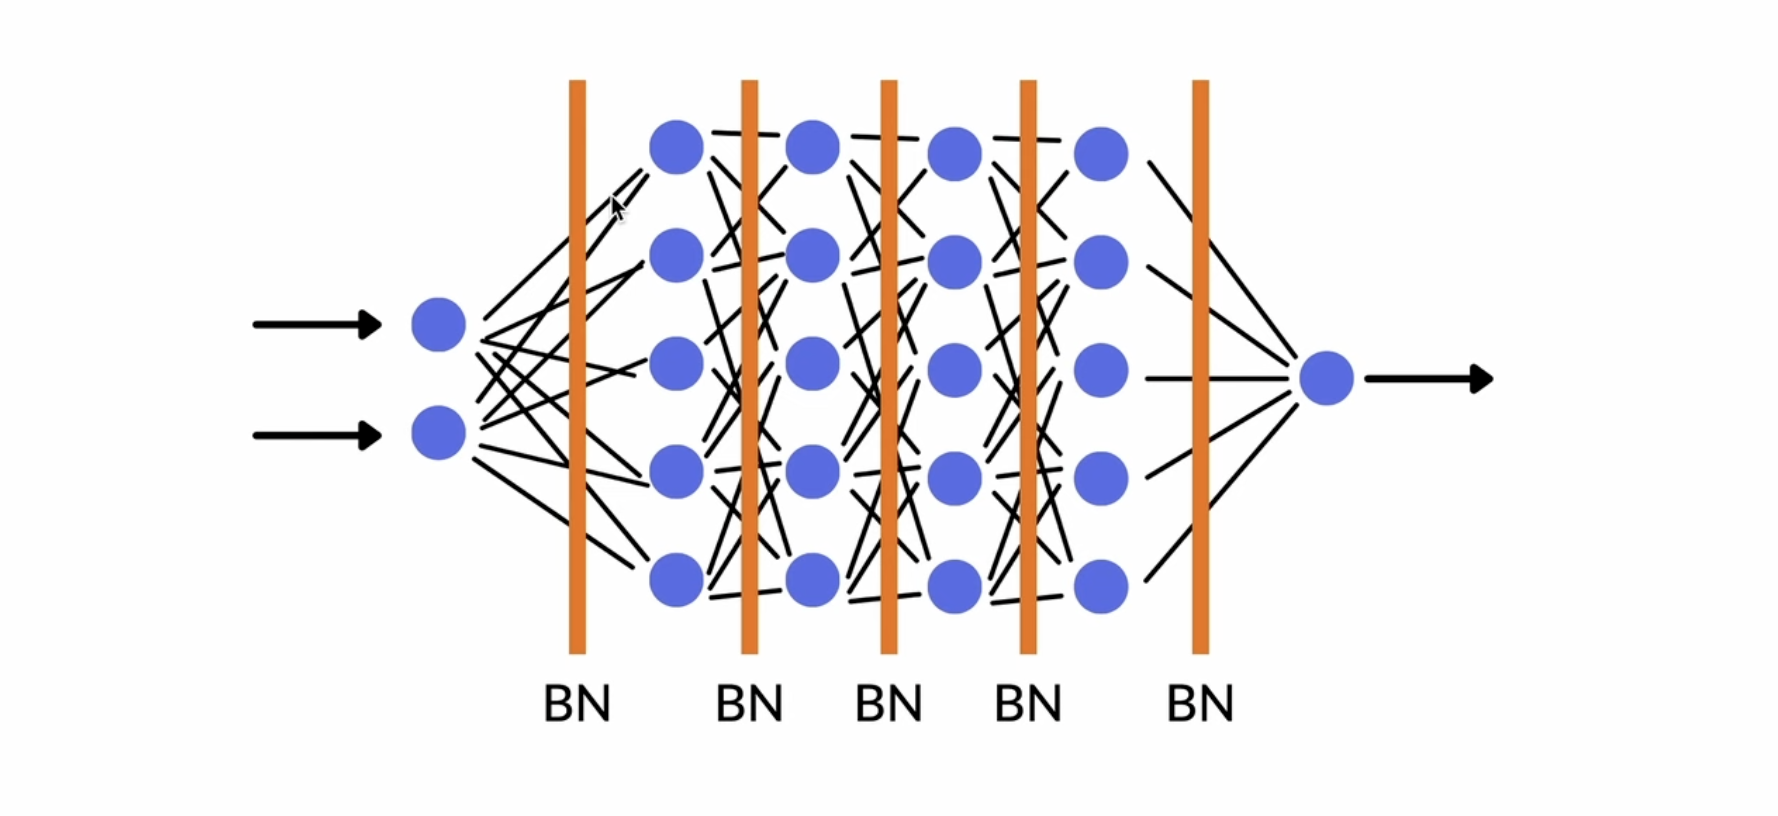

---

## 2. Layer Normalization (`nn.LayerNorm`)

**Normalize over:** Channel + Spatial (C, H, W) — **sample တစ်ခုချင်းစီ** အတွက်

```
(N, C, H, W)
    ↑  ↑  ↑
    │  │  │
    └──┴──┘  ← ဒီ 3 dimensions (C, H, W) ပေါ်မှာ mean/var တွက်
 ↑
 └───────── sample N တစ်ခုစီ အတွက် mean/var တစ်ခုစီ ရမယ်
```

**Sample 0** ရဲ့ **channels + spatial** values **အကုန်လုံး**ကနေ mean/var **တစ်ခုတည်း** တွက်တယ်။

### Key Points:
- **Batch size** နဲ့ မဆိုင် — sample တစ်ခုချင်းစီ independent
- Batch size = 1 ဖြစ်လည်း ကောင်းကောင်း အလုပ်လုပ်တယ်
- **Transformer, RNN, NLP** tasks မှာ standard
- CNN မှာ BatchNorm ထက် performance နည်းနည်း ကျတတ်, but batch size ငယ်ရင် ပိုကောင်းနိုင်

In [ ]:
# --- 2. Layer Normalization ---
# LayerNorm(normalized_shape) — C, H, W dimensions ပေါ်မှာ normalize
ln = nn.LayerNorm(normalized_shape=[4, 3, 3])  # (C=4, H=3, W=3)

ln_out = ln(x)

print("=== Layer Normalization ===")
print(f"Input shape:  {x.shape}")
print(f"Output shape: {ln_out.shape}")
print()

# Sample တစ်ခုချင်းစီ စစ်ကြည့်
for n in range(2):
    vals = x[n]         # shape: (C=4, H=3, W=3) → 36 values
    out_vals = ln_out[n]
    print(f"  Sample {n}: input mean={vals.mean():.4f}, std={vals.std():.4f}"
          f"  →  output mean={out_vals.mean():.6f}, std={out_vals.std():.4f}")

print()
print("✅ Sample တစ်ခုချင်းစီ (C,H,W values အကုန်) mean≈0, std≈1 ဖြစ်သွားတယ်")
print("   Batch dimension နဲ့ လုံးဝ မဆိုင် — batch size=1 ဖြစ်လည်း အလုပ်လုပ်တယ်")
print(f"   Learnable params: γ={ln.weight.shape}, β={ln.bias.shape}")

---

## 3. Instance Normalization (`nn.InstanceNorm2d`)

**Normalize over:** Spatial only (H, W) — **sample + channel တစ်ခုချင်းစီ** အတွက်

```
(N, C, H, W)
          ↑  ↑
          │  │
          └──┘  ← ဒီ 2 dimensions (H, W) ပေါ်မှာ mean/var တွက်
 ↑  ↑
 │  └────── channel C တစ်ခုစီ
 └───────── sample N တစ်ခုစီ  → (N, C) combination တစ်ခုစီ mean/var ရမယ်
```

**Sample 0, Channel 0** ရဲ့ **spatial values** (3x3 = 9 values) ကနေပဲ mean/var တွက်တယ်။

### Key Points:
- Sample တစ်ခုရဲ့ channel တစ်ခုရဲ့ **spatial statistics ပဲ** normalize
- **Style Transfer** (AdaIN, Neural Style Transfer) ရဲ့ core technique
- Style = feature map ရဲ့ mean/var → InstanceNorm က style information ကို strip out
- Default: **learnable parameters (γ, β) မပါ** (`affine=False`)

In [ ]:
# --- 3. Instance Normalization ---
# InstanceNorm2d(num_features) — channel count
# affine=False (default) → learnable γ, β မပါ
inst_norm = nn.InstanceNorm2d(num_features=4, affine=True)

inst_out = inst_norm(x)

print("=== Instance Normalization ===")
print(f"Input shape:  {x.shape}")
print(f"Output shape: {inst_out.shape}")
print()

# Sample + Channel combination တစ်ခုချင်းစီ စစ်ကြည့်
for n in range(2):
    for c in range(4):
        vals = x[n, c]          # shape: (H=3, W=3) → 9 values only
        out_vals = inst_out[n, c]
        print(f"  Sample {n}, Ch {c}: input mean={vals.mean():.4f}, std={vals.std():.4f}"
              f"  →  output mean={out_vals.mean():.6f}, std={out_vals.std():.4f}")
    print()

print("✅ (Sample, Channel) pair တစ်ခုချင်းစီရဲ့ spatial values mean≈0, std≈1")
print("   Spatial dimension (H,W) ပေါ်မှာပဲ normalize — 9 values ပေါ် stats တွက်")
print("   → Style Transfer မှာ style info = per-channel mean/var ကို remove လုပ်ဖို့ သုံးတယ်")

---

## 4. Group Normalization (`nn.GroupNorm`)

**Normalize over:** Channel groups + Spatial (G channels, H, W) — **sample + group တစ်ခုချင်းစီ**

```
(N, C, H, W)    eg. C=4, num_groups=2
    ├──┤  ↑  ↑
    G1 │  │  │   ← Group 1 (Ch 0,1) ရဲ့ spatial values ပေါ်မှာ mean/var
    ├──┤  │  │
    G2    │  │   ← Group 2 (Ch 2,3) ရဲ့ spatial values ပေါ်မှာ mean/var
          └──┘
```

Channels ကို **groups** ခွဲ (eg. 4 channels → 2 groups, each 2 channels)။ Group တစ်ခုထဲက channels + spatial values ပေါ်မှာ stats တွက်။

### Key Points:
- **BatchNorm + InstanceNorm ကြား** compromise
- `num_groups=1` → LayerNorm နဲ့ equivalent
- `num_groups=C` → InstanceNorm နဲ့ equivalent
- Batch size **ငယ်လည်း** stable (batch statistics မသုံးလို့)
- **Object Detection, Segmentation** (small batch) မှာ popular — FAIR (Facebook AI Research) introduce

In [ ]:
# --- 4. Group Normalization ---
# GroupNorm(num_groups, num_channels)
# 4 channels ကို 2 groups ခွဲ → Group 0: Ch[0,1], Group 1: Ch[2,3]
gn = nn.GroupNorm(num_groups=2, num_channels=4)

gn_out = gn(x)

print("=== Group Normalization (2 groups, 4 channels) ===")
print(f"Input shape:  {x.shape}")
print(f"Output shape: {gn_out.shape}")
print(f"Groups: Ch[0,1] = Group 0, Ch[2,3] = Group 1")
print()

# Group တစ်ခုချင်းစီ စစ်ကြည့်
for n in range(2):
    for g, ch_range in enumerate([(0, 2), (2, 4)]):
        vals = x[n, ch_range[0]:ch_range[1]]        # shape: (2, 3, 3) → 18 values
        out_vals = gn_out[n, ch_range[0]:ch_range[1]]
        print(f"  Sample {n}, Group {g} (Ch{ch_range[0]}-{ch_range[1]-1}): "
              f"input mean={vals.mean():.4f}, std={vals.std():.4f}"
              f"  →  output mean={out_vals.mean():.6f}, std={out_vals.std():.4f}")
    print()

print("✅ (Sample, Group) pair ရဲ့ channels+spatial values ပေါ်မှာ mean≈0, std≈1")
print()

# Special cases ပြ
print("=== Special Cases ===")
gn_as_ln = nn.GroupNorm(num_groups=1, num_channels=4)  # 1 group = LayerNorm
gn_as_in = nn.GroupNorm(num_groups=4, num_channels=4)  # groups=channels = InstanceNorm
print(f"  num_groups=1 (all channels = 1 group) → LayerNorm equivalent")
print(f"  num_groups=C=4 (each channel = 1 group) → InstanceNorm equivalent")

---

## Visual Comparison: ဘယ် Dimensions ပေါ်မှာ Normalize လုပ်လဲ

အောက်က diagram မှာ **အပြာရောင် cells** = mean/var တွက်ဖို့ **ပေါင်းတဲ့ values** (same color = same stat group)

In [ ]:
# --- Visual Comparison: Normalization Dimensions ---
# (N=3, C=4) grid ပေါ်မှာ ဘယ် cells တွေ group ဖြစ်လဲ ပြမယ်
# Row = C (channels), Column = N (batch samples)
# Each cell = one (H,W) spatial block

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
N, C = 3, 4  # 3 samples, 4 channels

norm_types = [
    ("Batch Norm", "per channel across batch"),
    ("Layer Norm", "per sample across channels"),
    ("Instance Norm", "per sample per channel"),
    ("Group Norm (G=2)", "per sample per group"),
]

# Color maps: same color = same normalization group
for idx, (title, subtitle) in enumerate(norm_types):
    ax = axes[idx]
    ax.set_xlim(0, N)
    ax.set_ylim(0, C)
    ax.set_xlabel("Batch (N)", fontsize=10)
    ax.set_ylabel("Channel (C)", fontsize=10)
    ax.set_title(f"{title}\n{subtitle}", fontsize=11, fontweight='bold')
    ax.set_xticks(np.arange(N) + 0.5)
    ax.set_xticklabels([f"N{i}" for i in range(N)])
    ax.set_yticks(np.arange(C) + 0.5)
    ax.set_yticklabels([f"C{i}" for i in range(C)])
    ax.set_aspect('equal')
    ax.invert_yaxis()

    colors_map = {
        # BatchNorm: same channel = same color (across batch)
        0: [[0,0,0,0], [1,1,1,1], [2,2,2,2], [3,3,3,3]],  # dummy, use channel-based
        # LayerNorm: same sample = same color
        1: [[0,1,2], [0,1,2], [0,1,2], [0,1,2]],
        # InstanceNorm: each cell unique
        2: [[0,1,2], [3,4,5], [6,7,8], [9,10,11]],
        # GroupNorm (G=2): Ch0,1 = group, Ch2,3 = group, per sample
        3: [[0,1,2], [0,1,2], [3,4,5], [3,4,5]],
    }

    cmap = plt.cm.Set3
    for c in range(C):
        for n in range(N):
            color_id = colors_map[idx][c][n]
            rect = mpatches.FancyBboxPatch(
                (n + 0.05, c + 0.05), 0.9, 0.9,
                boxstyle="round,pad=0.05",
                facecolor=cmap(color_id / 12),
                edgecolor='black', linewidth=1.5
            )
            ax.add_patch(rect)
            # Label
            ax.text(n + 0.5, c + 0.5, f"N{n}\nC{c}",
                   ha='center', va='center', fontsize=8, fontweight='bold')

plt.suptitle("Normalization Comparison — Same Color = Same Group (같은 mean/var 공유)",
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print("📊 Same color = same normalization group (mean/var ကို အတူတွက်တဲ့ cells)")
print("   Batch Norm:    channel (row) အတိုင်း → batch samples အကုန် group")
print("   Layer Norm:    sample (column) အတိုင်း → channels အကုန် group")
print("   Instance Norm: cell တစ်ခုချင်းစီ → spatial values ပေါ် independently")
print("   Group Norm:    sample + channel group → channels ကို subgroup ခွဲ")

In [ ]:
# --- Side-by-Side Output Comparison ---
# Input tensor တစ်ခုတည်း → 4 norm types apply ပြီး output ယှဉ်ကြည့်

bn_layer = nn.BatchNorm2d(4)
ln_layer = nn.LayerNorm([4, 3, 3])
in_layer = nn.InstanceNorm2d(4, affine=True)
gn_layer = nn.GroupNorm(2, 4)

# All in training mode
for layer in [bn_layer, ln_layer, in_layer, gn_layer]:
    layer.train()

outputs = {
    'Input': x,
    'BatchNorm': bn_layer(x),
    'LayerNorm': ln_layer(x),
    'InstanceNorm': in_layer(x),
    'GroupNorm': gn_layer(x),
}

# --- Sample 0 ရဲ့ 4 channels visualization ---
fig, axes = plt.subplots(5, 4, figsize=(14, 14))
for row, (name, tensor) in enumerate(outputs.items()):
    for c in range(4):
        data = tensor[0, c].detach().numpy()  # Sample 0, Channel c
        im = axes[row][c].imshow(data, cmap='RdBu_r', vmin=-3, vmax=3)
        axes[row][c].set_title(f"Ch{c} [{data.mean():.2f}±{data.std():.2f}]", fontsize=9)
        axes[row][c].axis('off')
    axes[row][0].set_ylabel(name, fontsize=12, fontweight='bold', rotation=0, labelpad=80)

plt.suptitle("Sample 0: Normalization Output Comparison (4 Channels)", fontsize=13)
fig.colorbar(im, ax=axes, shrink=0.6, label='Value')
plt.tight_layout()
plt.show()

---

## Summary: ဘယ်အချိန် ဘာသုံးလဲ

| Norm Type | PyTorch | Normalize Over | Best For | Batch Size Dependency |
|-----------|---------|---------------|----------|:-----:|
| **Batch Norm** | `nn.BatchNorm2d(C)` | (N, H, W) per channel | CNN classification (ResNet, VGG) | ⚠️ Large batch needed |
| **Layer Norm** | `nn.LayerNorm([C,H,W])` | (C, H, W) per sample | Transformer, RNN, NLP | ✅ Independent |
| **Instance Norm** | `nn.InstanceNorm2d(C)` | (H, W) per sample+channel | Style Transfer, GAN | ✅ Independent |
| **Group Norm** | `nn.GroupNorm(G, C)` | (C/G, H, W) per sample+group | Detection, Segmentation | ✅ Independent |

### Quick Decision Guide

```
Batch size ကြီးတယ် (≥32)?
  ├─ YES → BatchNorm ✅ (CNN standard, fastest converge)
  └─ NO  → Batch size ငယ် (1~8)?
             ├─ CNN task → GroupNorm ✅
             ├─ Style Transfer → InstanceNorm ✅
             └─ Transformer/RNN → LayerNorm ✅
```

### CNN Model Architecture Example

```python
# --- Standard CNN Block (BatchNorm) ---
nn.Sequential(
    nn.Conv2d(64, 128, 3, padding=1),
    nn.BatchNorm2d(128),      # ← Conv output channels နဲ့ match ရမယ်
    nn.ReLU(),
)

# --- Small Batch CNN (GroupNorm) ---
nn.Sequential(
    nn.Conv2d(64, 128, 3, padding=1),
    nn.GroupNorm(32, 128),     # ← 128 channels ÷ 32 groups = 4 ch/group
    nn.ReLU(),
)
```

> **Order:** `Conv → Norm → Activation` — ဒါက standard order။ Norm ကို Conv ပြီး Activation မတိုင်ခင် ထည့်တယ်။